<a href="https://colab.research.google.com/github/Yushan2008/Python_PratikumAnalisisData/blob/main/PratikumAnalisisData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q kaggle
from google.colab import files
files.upload() # Pilih file kaggle.json yang baru saja diunduh

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"yushanhakim","key":"32f26f6400ae4f3c5f8a29c6cdc53f45"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
# Mencari dataset
!kaggle datasets list -s &quot;ecommerce data&quot;
# Download dataset (Ganti &#39;carrie1/ecommerce-data&#39; sesuai dataset pilihan)
!kaggle datasets download -d carrie1/ecommerce-data
# Ekstrak file zip yang terunduh
!unzip ecommerce-data.zip

/bin/bash: line 1: quot: command not found
/bin/bash: line 1: ecommerce: command not found
/bin/bash: line 1: quot: command not found
usage: kaggle datasets list [-h] [--sort-by SORT_BY] [--size SIZE]
                            [--file-type FILE_TYPE] [--license LICENSE_NAME]
                            [--tags TAG_IDS] [-s SEARCH] [-m] [--user USER]
                            [-p PAGE] [-v] [--max-size MAX_SIZE]
                            [--min-size MIN_SIZE]
kaggle datasets list: error: argument -s/--search: expected one argument
Dataset URL: https://www.kaggle.com/datasets/carrie1/ecommerce-data
License(s): unknown
ecommerce-data.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  ecommerce-data.zip
replace data.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: yes
  inflating: data.csv                


Langkah 1: Persiapan Library &amp; Data

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data.csv', encoding='latin1')
print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  


In [21]:
df_praktikum = pd.read_csv('/content/data_praktikum_analisis_data (1) - data_praktikum_analisis_data (1).csv')
display(df_praktikum.head())

,Order_ID,CustomerID,Order_Date,Product_Category,Quantity,Price_Per_Unit,Ad_Budget,Total_Sales
0,1001,5039,2023-08-19,Books,4,1184000.0,982000.0,4736000.0
1,1002,5029,2023-08-29,Fashion,5,1733000.0,3513000.0,8665000.0
2,1003,5015,2023-02-21,Fashion,4,1767000.0,2117000.0,7068000.0
3,1004,5043,2023-04-06,Fashion,2,512000.0,4384000.0,1024000.0
4,1005,5008,2023-08-10,Home Decor,2,1820000.0,2625000.0,3640000.0


Langkah 2: Inspeksi &amp; Pembersihan Data (Data Cleaning)

In [10]:
# 1. Cek Tipe Data
print("Informasi Data:")
df.info()

Informasi Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [11]:
# 2. Cek Data Kosong
print("\nJumlah data kosong per kolom:")
print(df.isnull().sum())


Jumlah data kosong per kolom:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


Berdasarkan `df.info()` dan `df.isnull().sum()`, kita bisa melihat bahwa kolom `Description` dan `CustomerID` memiliki nilai yang hilang. Kolom `UnitPrice` dan `Quantity` memiliki tipe data numerik yang sesuai, dan `InvoiceDate` adalah objek, yang perlu kita ubah ke tipe data datetime.

In [12]:
# 3. Pembersihan

# Menghapus baris dengan UnitPrice <= 0 (harga negatif atau nol)
print(f"Jumlah baris sebelum menghapus harga <= 0: {len(df)}")
df = df[df['UnitPrice'] > 0]
print(f"Jumlah baris setelah menghapus harga <= 0: {len(df)}")

# Mengonversi kolom 'InvoiceDate' ke tipe datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print("\nTipe data setelah konversi InvoiceDate:")
df.info()

Jumlah baris sebelum menghapus harga <= 0: 541909
Jumlah baris setelah menghapus harga <= 0: 539392

Tipe data setelah konversi InvoiceDate:
<class 'pandas.core.frame.DataFrame'>
Index: 539392 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    539392 non-null  object        
 1   StockCode    539392 non-null  object        
 2   Description  539392 non-null  object        
 3   Quantity     539392 non-null  int64         
 4   InvoiceDate  539392 non-null  datetime64[ns]
 5   UnitPrice    539392 non-null  float64       
 6   CustomerID   406789 non-null  float64       
 7   Country      539392 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 37.0+ MB


/tmp/ipykernel_10371/780053117.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


Langkah 3: Analisis &amp; Visualisasi

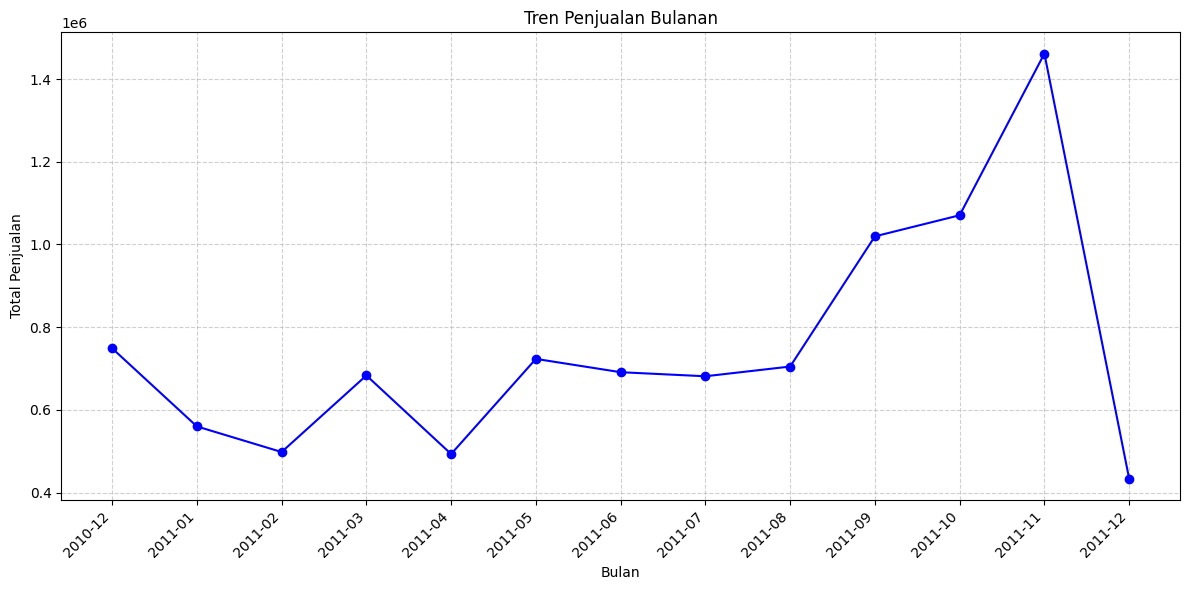

In [15]:
# Menghitung total penjualan
df['Total_Sales'] = df['Quantity'] * df['UnitPrice']

# Ekstrak bulan dari InvoiceDate (sudah dalam format datetime)
df['Month'] = df['InvoiceDate'].dt.to_period('M').astype(str)

# Menghitung penjualan bulanan
monthly_sales = df.groupby('Month')['Total_Sales'].sum()

# Visualisasi tren penjualan bulanan
plt.figure(figsize=(12,6))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', color='b')
plt.title('Tren Penjualan Bulanan')
plt.xlabel('Bulan')
plt.ylabel('Total Penjualan')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

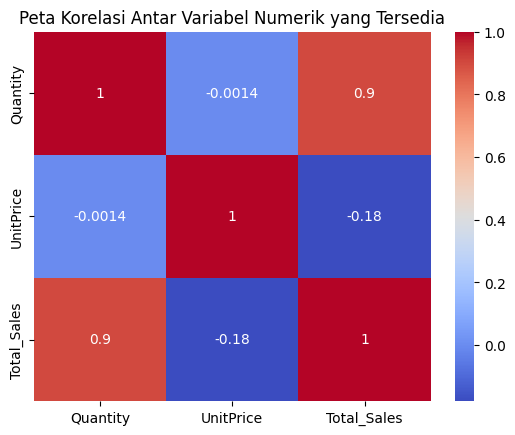

In [22]:
correlation = df[['Quantity', 'UnitPrice', 'Total_Sales']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Peta Korelasi Antar Variabel Numerik yang Tersedia')
plt.show()

Tugas Siswa (Kelompok Sebangku)

1. Identifikasi Produk &quot;Underperformer&quot;

Jumlah kategori produk dengan harga di atas rata-rata (1024640.00) dan kuantitas penjualan di bawah kuartil pertama (84): 1

Top Kategori Produk Underperformer berdasarkan Harga Rata-Rata:


,Product_Category,Total_Quantity,Avg_Price_Per_Unit
4,Home Decor,71,1.029583e+06


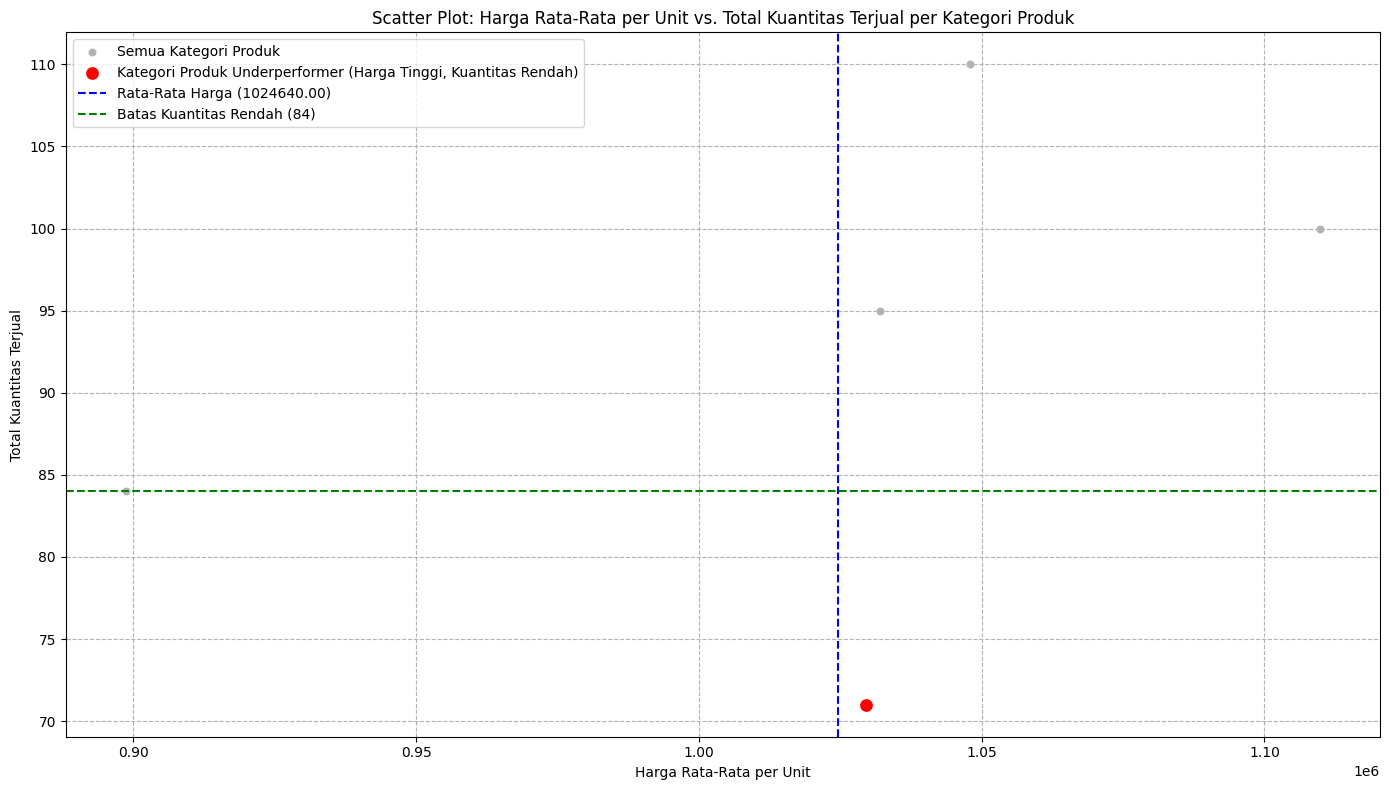

In [23]:
# 1. Agregasi data berdasarkan Product_Category untuk mendapatkan total kuantitas dan rata-rata harga per unit
product_summary_praktikum = df_praktikum.groupby('Product_Category').agg(
    Total_Quantity=('Quantity', 'sum'),
    Avg_Price_Per_Unit=('Price_Per_Unit', 'mean')
).reset_index()

# 2. Menghitung rata-rata Price_Per_Unit keseluruhan untuk referensi
overall_avg_price_per_unit_praktikum = df_praktikum['Price_Per_Unit'].mean()

# 3. Menentukan ambang batas untuk 'kuantitas rendah' (misalnya, kuartil pertama dari Total_Quantity)
low_quantity_threshold_praktikum = product_summary_praktikum['Total_Quantity'].quantile(0.25)

# 4. Mengidentifikasi kategori produk 'underperformer':
#    Avg_Price_Per_Unit di atas rata-rata keseluruhan DAN Total_Quantity di bawah ambang batas rendah
underperformers_praktikum = product_summary_praktikum[
    (product_summary_praktikum['Avg_Price_Per_Unit'] > overall_avg_price_per_unit_praktikum) &
    (product_summary_praktikum['Total_Quantity'] <= low_quantity_threshold_praktikum)
]

print(f"Jumlah kategori produk dengan harga di atas rata-rata ({overall_avg_price_per_unit_praktikum:.2f}) dan kuantitas penjualan di bawah kuartil pertama ({low_quantity_threshold_praktikum:.0f}): {len(underperformers_praktikum)}")
print("\nTop Kategori Produk Underperformer berdasarkan Harga Rata-Rata:")
display(underperformers_praktikum.sort_values(by='Avg_Price_Per_Unit', ascending=False).head(10))

# 5. Visualisasi menggunakan Scatter Plot
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=product_summary_praktikum,
    x='Avg_Price_Per_Unit',
    y='Total_Quantity',
    alpha=0.6,
    color='gray',
    label='Semua Kategori Produk'
)

sns.scatterplot(
    data=underperformers_praktikum,
    x='Avg_Price_Per_Unit',
    y='Total_Quantity',
    color='red',
    s=100, # Ukuran titik lebih besar untuk highlight
    label='Kategori Produk Underperformer (Harga Tinggi, Kuantitas Rendah)'
)

plt.axvline(x=overall_avg_price_per_unit_praktikum, color='blue', linestyle='--', label=f'Rata-Rata Harga ({overall_avg_price_per_unit_praktikum:.2f})')
plt.axhline(y=low_quantity_threshold_praktikum, color='green', linestyle='--', label=f'Batas Kuantitas Rendah ({low_quantity_threshold_praktikum:.0f})')

plt.title('Scatter Plot: Harga Rata-Rata per Unit vs. Total Kuantitas Terjual per Kategori Produk')
plt.xlabel('Harga Rata-Rata per Unit')
plt.ylabel('Total Kuantitas Terjual')
# Menggunakan skala logaritmik untuk X dan Y jika distribusi datanya sangat luas
# plt.xscale('log')
# plt.yscale('log')
plt.grid(True, which="both", ls="--", c='0.7')
plt.legend()
plt.tight_layout()
plt.show()

2. Segmentasi Pelanggan (RFM Analysis)

In [24]:
# Pastikan kolom 'Order_Date' bertipe datetime
df_praktikum['Order_Date'] = pd.to_datetime(df_praktikum['Order_Date'])

# Ambil tanggal terakhir dalam dataset untuk perhitungan recency
latest_date_praktikum = df_praktikum['Order_Date'].max()

# Hitung Recency, Frequency, dan Monetary
rfm_df_praktikum = df_praktikum.groupby('CustomerID').agg(
    Recency=('Order_Date', lambda date: (latest_date_praktikum - date.max()).days), # Hari sejak pembelian terakhir
    Frequency=('Order_ID', 'nunique'), # Jumlah transaksi unik
    Monetary=('Total_Sales', 'sum') # Total pengeluaran
).reset_index()

print("RFM DataFrame:")
display(rfm_df_praktikum.head())

print("\nStatistik Deskriptif RFM:")
display(rfm_df_praktikum[['Recency', 'Frequency', 'Monetary']].describe())

RFM DataFrame:


,CustomerID,Recency,Frequency,Monetary
0,5001,212,4,8562000.0
1,5002,76,4,6931000.0
2,5003,117,3,9433000.0
3,5004,195,3,15368000.0
4,5005,22,2,9105000.0



Statistik Deskriptif RFM:


,Recency,Frequency,Monetary
count,48.000000,48.000000,4.800000e+01
mean,117.520833,3.125000,9.543271e+06
std,91.747570,1.733586,6.578666e+06
min,0.000000,1.000000,3.190000e+05
25%,34.750000,2.000000,4.211250e+06
50%,110.500000,3.000000,7.863500e+06
75%,196.250000,4.000000,1.372100e+07
max,315.000000,7.000000,2.630900e+07


3. Analisis Kontribusi Kategori

Kontribusi Penjualan per Kategori Produk:


,Percentage_Contribution
Product_Category,
Electronics,24.91%
Books,23.48%
Fashion,21.08%
Gadget,15.40%
Home Decor,15.14%


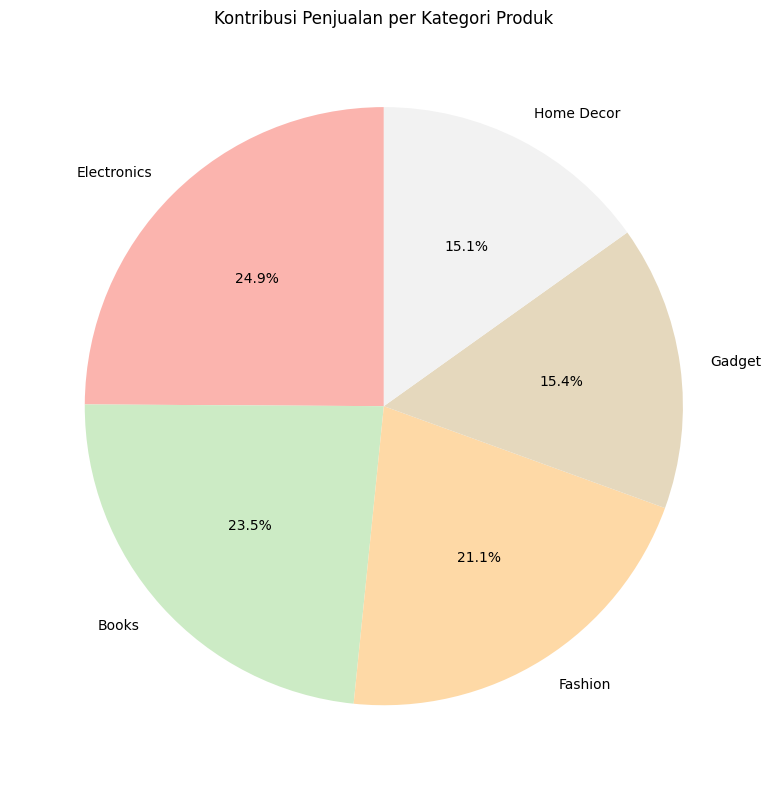

In [25]:
# Hitung total penjualan per kategori
category_sales = df_praktikum.groupby('Product_Category')['Total_Sales'].sum().sort_values(ascending=False)

# Hitung persentase kontribusi
total_overall_sales = category_sales.sum()
category_contribution = (category_sales / total_overall_sales) * 100

print("Kontribusi Penjualan per Kategori Produk:")
display(category_contribution.to_frame(name='Percentage_Contribution').style.format('{:.2f}%'))

# Visualisasi Kontribusi Kategori
plt.figure(figsize=(10, 8))
category_sales.plot(kind='pie', autopct='%1.1f%%', startangle=90, cmap='Pastel1')
plt.title('Kontribusi Penjualan per Kategori Produk')
plt.ylabel('') # Hapus label y-axis untuk pie chart
plt.tight_layout()
plt.show()


4. Uji Hipotesis Sederhana

In [27]:
from scipy import stats
import numpy as np # Import numpy for np.isnan

# 1. Hitung median dari Ad_Budget
median_ad_budget = df_praktikum['Ad_Budget'].median()
print(f"Median Ad_Budget: {median_ad_budget:.2f}")

# 2. Bagi data menjadi dua kelompok (Iklan Tinggi vs Iklan Rendah)
df_high_ad = df_praktikum[df_praktikum['Ad_Budget'] > median_ad_budget]
df_low_ad = df_praktikum[df_praktikum['Ad_Budget'] <= median_ad_budget]

print(f"\nJumlah data dengan Iklan Tinggi: {len(df_high_ad)}")
print(f"Jumlah data dengan Iklan Rendah: {len(df_low_ad)}")

# Extract Total_Sales for each group and drop any potential NaNs
total_sales_high_ad = df_high_ad['Total_Sales'].dropna()
total_sales_low_ad = df_low_ad['Total_Sales'].dropna()

# 3. Bandingkan rata-rata Total_Sales dari kedua kelompok
mean_sales_high_ad = total_sales_high_ad.mean()
mean_sales_low_ad = total_sales_low_ad.mean()

print(f"\nRata-rata Total_Sales untuk Iklan Tinggi: {mean_sales_high_ad:.2f}")
print(f"Rata-rata Total_Sales untuk Iklan Rendah: {mean_sales_low_ad:.2f}")

# 4. Lakukan uji t independen (Independent Samples t-test)
t_stat = np.nan
p_value = np.nan

# Check if there's enough data and non-zero variance to perform the t-test
if len(total_sales_high_ad) > 1 and len(total_sales_low_ad) > 1 and \
   total_sales_high_ad.var() > 0 and total_sales_low_ad.var() > 0:
    # Asumsi: variansi tidak sama (Welch's t-test)
    t_stat, p_value = stats.ttest_ind(total_sales_high_ad, total_sales_low_ad, equal_var=False)

    print(f"\nStatistik Uji T: {t_stat:.2f}")
    print(f"P-value: {p_value:.3f}")

    # Interpretasi hasil
    alpha = 0.05 # Tingkat signifikansi
    if p_value < alpha:
        print(f"Karena p-value ({p_value:.3f}) < alpha ({alpha}), kita menolak hipotesis nol.")
        print("Ada bukti signifikan bahwa peningkatan Ad_Budget di atas median menghasilkan peningkatan Total_Sales yang signifikan.")
    else:
        print(f"Karena p-value ({p_value:.3f}) >= alpha ({alpha}), kita gagal menolak hipotesis nol.")
        print("Tidak ada bukti signifikan bahwa peningkatan Ad_Budget di atas median menghasilkan peningkatan Total_Sales yang signifikan.")
else:
    print("\nUji t tidak dapat dilakukan: Salah satu atau kedua kelompok memiliki jumlah sampel kurang dari 2 atau variansi nol dalam 'Total_Sales' setelah membersihkan NaN.")
    print("Oleh karena itu, tidak ada kesimpulan yang dapat ditarik mengenai hipotesis.")


Median Ad_Budget: 2722500.00

Jumlah data dengan Iklan Tinggi: 75
Jumlah data dengan Iklan Rendah: 75

Rata-rata Total_Sales untuk Iklan Tinggi: 3156275.36
Rata-rata Total_Sales untuk Iklan Rendah: 3247216.22

Statistik Uji T: -0.22
P-value: 0.829
Karena p-value (0.829) >= alpha (0.05), kita gagal menolak hipotesis nol.
Tidak ada bukti signifikan bahwa peningkatan Ad_Budget di atas median menghasilkan peningkatan Total_Sales yang signifikan.


In [30]:
# Tentukan kuartil untuk Recency, Frequency, dan Monetary
# Recency: Skor 5 untuk nilai terendah (paling baru), 1 untuk nilai tertinggi (paling lama)
rfm_df_praktikum['R_Score'] = rfm_df_praktikum['Recency'].rank(method='first', ascending=False).astype(int)

# Frequency: Skor 5 untuk nilai tertinggi (paling sering), 1 untuk nilai terendah
rfm_df_praktikum['F_Score'] = rfm_df_praktikum['Frequency'].rank(method='first', ascending=True).astype(int)

# Monetary: Skor 5 untuk nilai tertinggi (pengeluaran terbesar), 1 untuk nilai terendah
rfm_df_praktikum['M_Score'] = rfm_df_praktikum['Monetary'].rank(method='first', ascending=True).astype(int)

# Normalisasi skor agar berada dalam rentang 1-5 (atau sesuai kebutuhan)
# Misalnya, bagi skor dengan jumlah unik CustomerID, lalu kalikan 5
max_r_rank = rfm_df_praktikum['R_Score'].max()
max_f_rank = rfm_df_praktikum['F_Score'].max()
max_m_rank = rfm_df_praktikum['M_Score'].max()

rfm_df_praktikum['R_Score'] = (rfm_df_praktikum['R_Score'] / max_r_rank * 5).astype(int)
rfm_df_praktikum['F_Score'] = (rfm_df_praktikum['F_Score'] / max_f_rank * 5).astype(int)
rfm_df_praktikum['M_Score'] = (rfm_df_praktikum['M_Score'] / max_m_rank * 5).astype(int)

# Pastikan skor minimum adalah 1
rfm_df_praktikum['R_Score'] = rfm_df_praktikum['R_Score'].replace(0, 1)
rfm_df_praktikum['F_Score'] = rfm_df_praktikum['F_Score'].replace(0, 1)
rfm_df_praktikum['M_Score'] = rfm_df_praktikum['M_Score'].replace(0, 1)

# Membuat RFM Segment dengan menggabungkan skor
rfm_df_praktikum['RFM_Segment'] = rfm_df_praktikum['R_Score'].astype(str) + rfm_df_praktikum['F_Score'].astype(str) + rfm_df_praktikum['M_Score'].astype(str)

# Membuat RFM Score agregat (bisa berupa rata-rata atau jumlah skor)
rfm_df_praktikum['RFM_Score'] = rfm_df_praktikum['R_Score'] + rfm_df_praktikum['F_Score'] + rfm_df_praktikum['M_Score']

print("RFM DataFrame dengan Skor dan Segmentasi:")
display(rfm_df_praktikum.head())

RFM DataFrame dengan Skor dan Segmentasi:


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,RFM_Score
0,5001,212,4,8562000.0,1,3,2,132,6
1,5002,76,4,6931000.0,2,3,2,232,7
2,5003,117,3,9433000.0,2,1,3,213,6
3,5004,195,3,15368000.0,1,2,3,123,6
4,5005,22,2,9105000.0,4,1,2,412,7


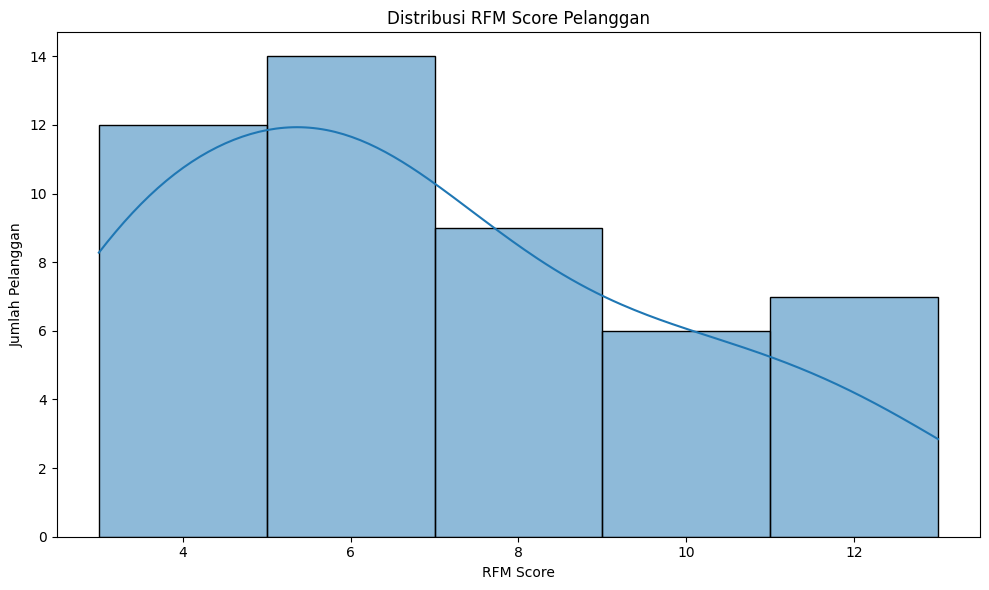

In [31]:
# Visualisasi Distribusi RFM Score
plt.figure(figsize=(10, 6))
sns.histplot(rfm_df_praktikum['RFM_Score'], bins=5, kde=True)
plt.title('Distribusi RFM Score Pelanggan')
plt.xlabel('RFM Score')
plt.ylabel('Jumlah Pelanggan')
plt.tight_layout()
plt.show()

# Analisis Rata-rata R, F, M per RFM Segment (opsional, jika ingin melihat karakteristik tiap segmen)
# Contoh: Top 10 Segmen berdasarkan jumlah pelanggan
# segment_counts = rfm_df_praktikum['RFM_Segment'].value_counts().head(10).index
# rfm_segment_analysis = rfm_df_praktikum[rfm_df_praktikum['RFM_Segment'].isin(segment_counts)].groupby('RFM_Segment')[['Recency', 'Frequency', 'Monetary']].mean().sort_values(by='Monetary', ascending=False)
# print("\nRata-rata RFM per Segment (Top 10):")
# display(rfm_segment_analysis)


5. Pendalaman Teknik: RFM Analysis

In [33]:
import datetime as dt
import pandas as pd

# Asumsi 'Snapshot_Date' adalah hari esok dari tanggal transaksi terakhir di data
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

# Hitung Recency, Frequency, dan Monetary
rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),  # Recency
    Frequency=('InvoiceNo', 'nunique'),                               # Frequency (count unique InvoiceNo)
    Monetary=('Total_Sales', 'sum')                                   # Monetary
).reset_index()

# Memberikan skor 1-5 (Semakin tinggi semakin baik)
# Recency: Skor 5 untuk nilai terendah (paling baru), 1 untuk nilai tertinggi (paling lama)
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1], duplicates='drop')
# Frequency: Skor 5 untuk nilai tertinggi (paling sering), 1 untuk nilai terendah
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5], duplicates='drop')
# Monetary: Skor 5 untuk nilai tertinggi (pengeluaran terbesar), 1 untuk nilai terendah
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5], duplicates='drop')

# Gabungkan skor menjadi satu segmen
rfm['RFM_Group'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

print("RFM DataFrame untuk df dengan Skor dan Segmentasi:")
display(rfm.head())


RFM DataFrame untuk df dengan Skor dan Segmentasi:


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Group
0,12346.0,326,2,0.00,1,2,1,121
1,12347.0,2,7,4310.00,5,4,5,545
2,12348.0,75,4,1797.24,2,3,4,234
3,12349.0,19,1,1757.55,4,1,4,414
4,12350.0,310,1,334.40,1,1,2,112


6. Pendalaman Teknik: Regresi Linear Sederhana

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Drop rows with NaN values in 'Total_Sales' or 'Ad_Budget' before splitting
df_cleaned = df_praktikum.dropna(subset=['Ad_Budget', 'Total_Sales'])

X = df_cleaned[['Ad_Budget']] # Fitur
y = df_cleaned['Total_Sales'] # Target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
print(f"Koefisien Iklan: {model.coef_[0]}")
print(f"Akurasi Model (R2 Score): {model.score(X_test, y_test)}")

Koefisien Iklan: 0.1841982749623798
Akurasi Model (R2 Score): -0.1956467472142791
